In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_data(csv_path):
    speeds = []
    ammo = []
    labels = []

    with open(csv_path, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)
        for row in reader:
            s = float(row[0])
            a = float(row[1])
            y = int(row[2])
            speeds.append(s)
            ammo.append(a)
            labels.append(y)

    X = np.column_stack((speeds, ammo))
    y = np.array(labels).reshape(-1, 1)
    return X, y

In [3]:
def normalize_features(X):

    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def compute_cost(X, y, theta):
    m = len(y)
    z = X @ theta
    h = sigmoid(z)
    p = 1e-10
    cost = -(1/m) * np.sum(y * np.log(h + p) +
                           (1 - y) * np.log(1 - h + p))
    return cost

In [5]:
def gradient_descent(X, y, alpha=0.1, num_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    costs = []

    for i in range(num_iters):
        z = X @ theta
        h = sigmoid(z)

        grad = (1/m) * (X.T @ (h - y))
        theta -= alpha * grad

        cost = compute_cost(X, y, theta)
        costs.append(cost)

    return theta, costs

In [6]:
csv_path = "/content/zombies_data - Sheet1.csv"

X_raw, y = load_data(csv_path)
X_norm, mu, sigma = normalize_features(X_raw)

m = X_norm.shape[0]
X_train = np.hstack((np.ones((m, 1)), X_norm))
learning_rate = 0.1
iterations = 5000

theta, costs = gradient_descent(X_train, y,alpha=learning_rate,num_iters=iterations)

print("Learned parameters (theta):")
print(theta)

Learned parameters (theta):
[[1.66661618]
 [7.86606051]
 [5.6538977 ]]


In [12]:
def predict_proba(speed, ammo, theta, mu, sigma):
    x = np.array([speed, ammo])
    x_norm = (x - mu) / sigma
    x_vec = np.hstack(([1.0], x_norm))
    prob = sigmoid(x_vec @ theta).item()
    return prob

speed_test = 25.0
ammo_test = 1.0

prob_survive = predict_proba(speed_test, ammo_test, theta, mu, sigma)
print(f"Survival probability for runner "f"{speed_test} km/h, {ammo_test} ammo clip(s): {prob_survive:.4f}")
print("Predicted label (1=Survive, 0=Infected):",1 if prob_survive >= 0.5 else 0)

Survival probability for runner 25.0 km/h, 1.0 ammo clip(s): 1.0000
Predicted label (1=Survive, 0=Infected): 1


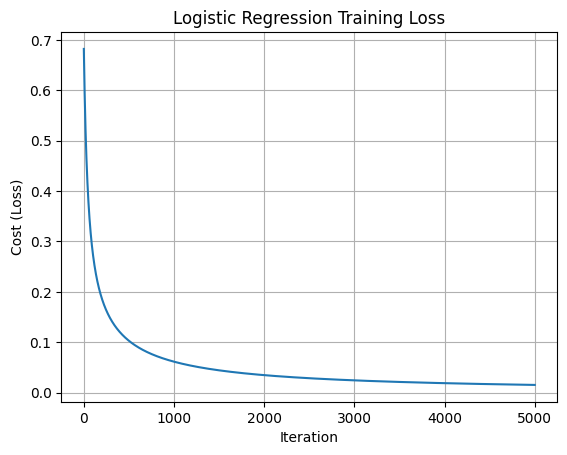

In [8]:
plt.figure()
plt.plot(range(len(costs)), costs)
plt.xlabel("Iteration")
plt.ylabel("Cost (Loss)")
plt.title("Logistic Regression Training Loss")
plt.grid(True)
plt.show()


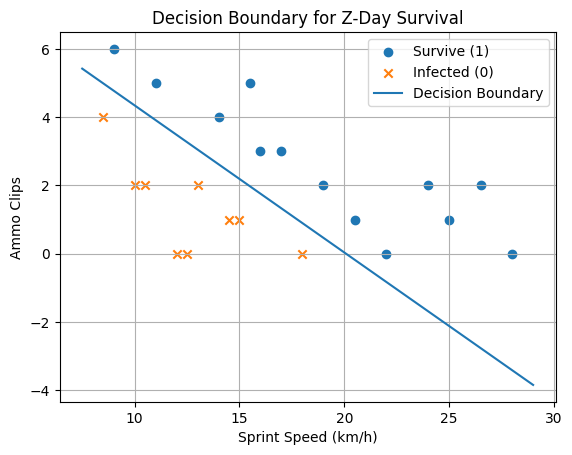

In [11]:
survive_idx = (y.flatten() == 1)
infect_idx = (y.flatten() == 0)

plt.figure()
plt.scatter(X_raw[survive_idx, 0],X_raw[survive_idx, 1],marker='o', label='Survive (1)')
plt.scatter(X_raw[infect_idx, 0],X_raw[infect_idx, 1],marker='x', label='Infected (0)')


theta0 = theta[0, 0]
theta1 = theta[1, 0]
theta2 = theta[2, 0]
mu1, mu2 = mu
s1, s2 = sigma

x1_vals = np.linspace(X_raw[:, 0].min() - 1,X_raw[:, 0].max() + 1, 100)

x2_vals = mu2 - (s2/theta2) * (theta0 + theta1 * (x1_vals - mu1) / s1)

plt.plot(x1_vals, x2_vals, label='Decision Boundary')

plt.xlabel("Sprint Speed (km/h)")
plt.ylabel("Ammo Clips")
plt.title("Decision Boundary for Z-Day Survival")
plt.legend()
plt.grid(True)
plt.show()